In [ ]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#Set Base Path
BASE = '/content/drive/MyDrive/Text Miners/Actual Work'
TASK3 = f'{BASE}/task3-combination'
print('Connected:', BASE)

Connected: /content/drive/MyDrive/Text Miners/Actual Work


In [ ]:
#Confirm connection
import os
print(os.listdir(BASE))

['data', 'pre-processing', 'features', 'task1-sentiments', 'task2-topics', 'task3-combination', 'dashboard', 'BeforeYouStart.docx']


In [ ]:
#Install required libraries
!pip install pandas numpy --quiet
import pandas as pd
import numpy as np
import os

In [ ]:
#Load data files
nss = pd.read_csv(f'{TASK3}/nss_scores.csv')
suggestions = pd.read_csv(f'{TASK3}/suggestions_by_aspect.csv')
supervised = pd.read_csv(f'{TASK3}/task3_supervised_output.csv')

print("nss_scores shape:", nss.shape)
print("suggestions shape:", suggestions.shape)
print("supervised shape:", supervised.shape)

nss_scores shape: (67516, 6)
suggestions shape: (73709, 3)
supervised shape: (380505, 7)


In [ ]:
#Keep only required columns and rename to match nss_output format
nss_merged_output = nss[['listing_id', 'aspect', 'NSS']].copy()
nss_merged_output = nss_merged_output.rename(columns={'NSS': 'NSS_score'})

print("nss_output shape:", nss_merged_output.shape)
print("Columns:", nss_merged_output.columns.tolist())
print(nss_merged_output.head(5))

nss_output shape: (67516, 3)
Columns: ['listing_id', 'aspect', 'NSS_score']
   listing_id         aspect  NSS_score
0       27934      amenities   0.500000
1       27934       check_in   0.666667
2       27934    cleanliness   1.000000
3       27934  communication   1.000000
4       27934       location   0.940000


In [ ]:
#Export
nss_merged_output.to_csv(f'{TASK3}/nss_merged_output.csv', index=False)
print("Saved nss_merged_output.csv")
print("Columns:", nss_merged_output.columns.tolist())
print("Total rows:", len(nss_merged_output))

Saved nss_merged_output.csv
Columns: ['listing_id', 'aspect', 'NSS_score']
Total rows: 67516


In [ ]:
#Sanity check: 5 listings with lowest cleanliness NSS
# Find listings with worst cleanliness scores
dirty_listings = (
    nss_merged_output[nss_merged_output['aspect'] == 'cleanliness']
    .sort_values('NSS_score')
    .head(5)
)

print("=== 5 listings with lowest cleanliness NSS ===")
print(dirty_listings)

# Show full aspect profile for these listings
listing_ids = dirty_listings['listing_id'].tolist()
print("\n=== Full NSS profile for these listings ===")
print(
    nss_merged_output[nss_merged_output['listing_id'].isin(listing_ids)]
    .sort_values(['listing_id', 'aspect'])
    .to_string()
)

# Load sentence-level detail and show actual sentences
sentence_detail = pd.read_csv(f'{TASK3}/sentence_aspect_polarity.csv')

dirty_sentences = (
    sentence_detail[
        (sentence_detail['listing_id'].isin(listing_ids)) &
        (sentence_detail['aspect'] == 'cleanliness')
    ]
    [['listing_id', 'polarity', 'compound_score', 'sentence']]
    .sort_values(['listing_id', 'polarity'])
)

print("\n=== Cleanliness sentences for 5 dirtiest listings ===")
for lid in listing_ids:
    subset = dirty_sentences[dirty_sentences['listing_id'] == lid]
    print(f"\n--- Listing {lid} ({len(subset)} cleanliness sentences) ---")
    for _, row in subset.iterrows():
        print(f"  [{row['polarity']} | {row['compound_score']:.3f}] {row['sentence'][:150]}")

=== 5 listings with lowest cleanliness NSS ===
                listing_id       aspect  NSS_score
15777             30338083  cleanliness       -1.0
60490  1315816093486782145  cleanliness       -1.0
18962             34513491  cleanliness       -1.0
24033             42344477  cleanliness       -1.0
24044             42347997  cleanliness       -1.0

=== Full NSS profile for these listings ===
                listing_id         aspect  NSS_score
15776             30338083       check_in  -1.000000
15777             30338083    cleanliness  -1.000000
15778             30338083  communication   1.000000
15779             30338083       location   1.000000
15780             30338083          value   1.000000
18962             34513491    cleanliness  -1.000000
18963             34513491       location   1.000000
24032             42344477      amenities  -1.000000
24033             42344477    cleanliness  -1.000000
24034             42344477  communication  -1.000000
24043             4

In [ ]:
#Sanity check: verify suggestions make sense
print("=== Suggestions column names ===")
print(suggestions.columns.tolist())
print("\n=== Suggestions shape:", suggestions.shape)

#Sample 2 suggestions per aspect
print("\n=== Sample suggestions per aspect ===")
for aspect in suggestions['predicted_aspect'].unique():
    sample = suggestions[suggestions['predicted_aspect'] == aspect].head(2)
    print(f"\n[{aspect}]")
    for _, row in sample.iterrows():
        print(f"  listing {row['listing_id']}: {str(row['comments'])[:120]}...")

=== Suggestions column names ===
['listing_id', 'predicted_aspect', 'comments']

=== Suggestions shape: (73709, 3)

=== Sample suggestions per aspect ===

[Transport & Accessibility]
  listing 27934: We stayed in the apartment for a week and we enjoyed it very much. Nuttee is a very nice host, and she did her best to a...
  listing 27934: Nuttee was a great host! I really enjoyed her apartment and she was absolutely lovely! She even had a bowl of fresh frui...

[Overall Experience]
  listing 27934: My girlfriend and I recently stayed in Nuttee's condo for a month.  It is a beautiful condo, with a great view, in a gre...
  listing 27934: Nuttee - wonderfull landlady. House very clean, with realy nice view. Usualy we stay at hotels, but next time we stay on...

[Neighbourhood & Dining]
  listing 27934: I stayed for one month at the condo and was realy pleased. 
<br/>The condo is at the 19th floor, quiet, modern and clean...
  listing 27934: Nuttee was a great host, she waited for us to a

In [ ]:
#Extra Checks just in case

In [ ]:
#Coverage check — how many listings have all 6 aspects
aspect_counts = nss_merged_output.groupby('listing_id')['aspect'].count()
full_coverage = (aspect_counts == 6).sum()
partial = (aspect_counts < 6).sum()

print(f"=== Listing Coverage ===")
print(f"Listings with all 6 aspects  : {full_coverage}")
print(f"Listings with partial aspects : {partial}")
print(f"Total unique listings         : {aspect_counts.shape[0]}")
print(f"\nAspect count distribution:")
print(aspect_counts.value_counts().sort_index())

=== Listing Coverage ===
Listings with all 6 aspects  : 4212
Listings with partial aspects : 12315
Total unique listings         : 16527

Aspect count distribution:
aspect
1    1507
2    1874
3    2415
4    2851
5    3668
6    4212
Name: count, dtype: int64


In [ ]:
#NSS distribution summary
print("=== Mean NSS per Aspect (descending) ===")
summary = (
    nss_merged_output.groupby('aspect')['NSS_score']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .round(4)
    .sort_values('mean', ascending=False)
)
print(summary)

=== Mean NSS per Aspect (descending) ===
                 mean     std  min  max  count
aspect                                        
communication  0.8935  0.3136 -1.0  1.0  14454
location       0.8853  0.2897 -1.0  1.0  14290
value          0.8777  0.3658 -1.0  1.0   9954
cleanliness    0.8517  0.3684 -1.0  1.0  13726
amenities      0.6368  0.5951 -1.0  1.0   9353
check_in       0.6130  0.6766 -1.0  1.0   5739


In [ ]:
#Cross-check with supervised output

#Compare rule-based NSS vs supervised predicted_sentiment per listing
#Convert supervised sentiment to numeric: positive=1, negative=-1, neutral=0
sentiment_map = {'positive': 1, 'negative': -1, 'neutral': 0}
supervised['sentiment_score'] = supervised['predicted_sentiment'].map(sentiment_map)

#Aggregate supervised output to listing-aspect level
supervised_agg = (
    supervised.groupby(['listing_id', 'predicted_aspect'])['sentiment_score']
    .mean()
    .reset_index()
    .rename(columns={'predicted_aspect': 'aspect', 'sentiment_score': 'supervised_score'})
)

print("=== Supervised output sample ===")
print(supervised_agg.head(10))
print(f"\nTotal rows: {len(supervised_agg)}")

=== Supervised output sample ===
   listing_id                      aspect  supervised_score
0       27934          Check-in & Arrival          0.666667
1       27934         Complaints & Issues          0.000000
2       27934      Facilities & Amenities          0.833333
3       27934  General Positive Sentiment          0.944444
4       27934      Neighbourhood & Dining          1.000000
5       27934          Overall Experience          0.538462
6       27934   Transport & Accessibility          1.000000
7       48736          Overall Experience          1.000000
8       55681          Check-in & Arrival          1.000000
9       55681  General Positive Sentiment          0.500000

Total rows: 67774


/tmp/ipykernel_4179/3523993189.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=aspect_order, patch_artist=True)


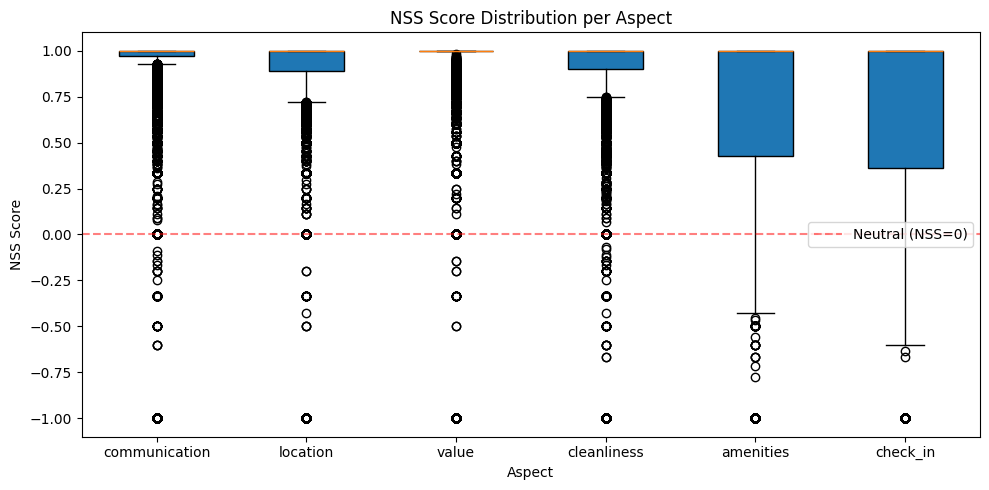

In [ ]:
#NSS distribution per aspect (box plot)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

aspect_order = (
    nss_merged_output.groupby('aspect')['NSS_score']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

data_to_plot = [nss_merged_output[nss_merged_output['aspect'] == a]['NSS_score'].values for a in aspect_order]

ax.boxplot(data_to_plot, labels=aspect_order, patch_artist=True)
ax.set_title('NSS Score Distribution per Aspect')
ax.set_ylabel('NSS Score')
ax.set_xlabel('Aspect')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Neutral (NSS=0)')
ax.legend()
plt.tight_layout()
plt.show()

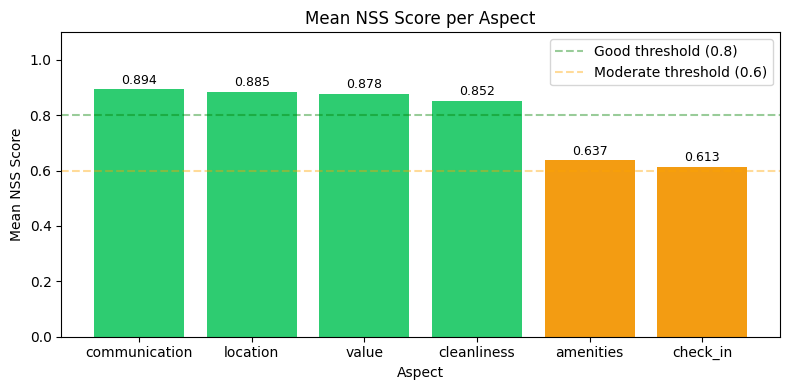

In [ ]:
#Mean NSS bar chart per aspect
fig, ax = plt.subplots(figsize=(8, 4))

mean_nss = (
    nss_merged_output.groupby('aspect')['NSS_score']
    .mean()
    .sort_values(ascending=False)
)

colors = ['#2ecc71' if v >= 0.8 else '#f39c12' if v >= 0.6 else '#e74c3c' for v in mean_nss.values]

bars = ax.bar(mean_nss.index, mean_nss.values, color=colors)
ax.set_title('Mean NSS Score per Aspect')
ax.set_ylabel('Mean NSS Score')
ax.set_xlabel('Aspect')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.4, label='Good threshold (0.8)')
ax.axhline(y=0.6, color='orange', linestyle='--', alpha=0.4, label='Moderate threshold (0.6)')

#Add value labels on bars
for bar, val in zip(bars, mean_nss.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

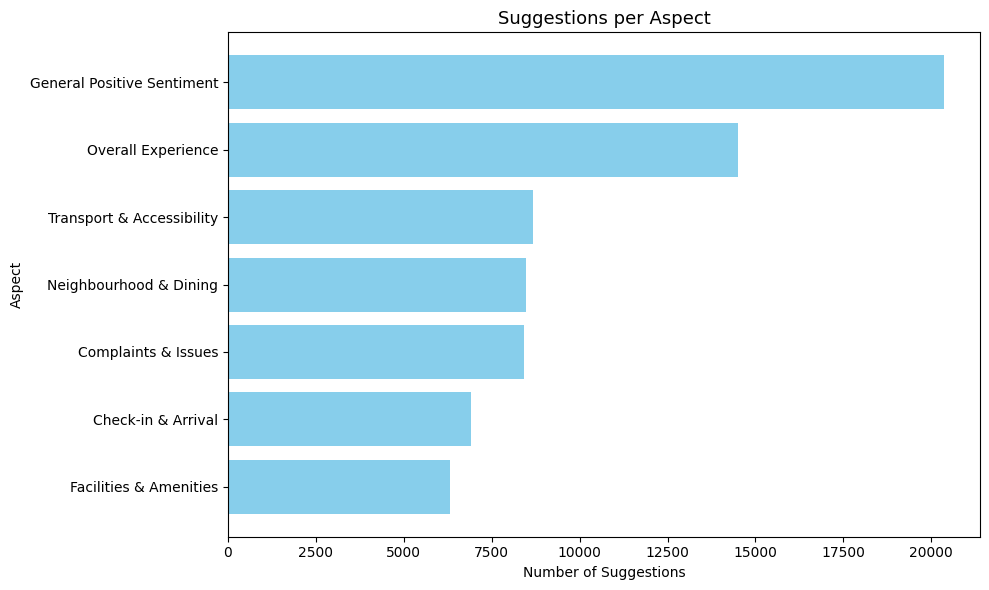

In [ ]:
import matplotlib.pyplot as plt

# Suggestions per aspect using your nss_output
fig, ax = plt.subplots(figsize=(10, 6))

suggestion_counts = suggestions['predicted_aspect'].value_counts().sort_values()

bars = ax.barh(suggestion_counts.index, suggestion_counts.values, color='skyblue')

ax.set_title('Suggestions per Aspect', fontsize=13)
ax.set_xlabel('Number of Suggestions')
ax.set_ylabel('Aspect')
plt.tight_layout()
plt.show()